In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from dotenv import load_dotenv
import pyarrow as pa, pyarrow.parquet as pq, pyarrow.compute as pc

In [2]:
sys.path.append(os.path.abspath("../src"))
from estimator import SegmentEstimator

In [3]:
load_dotenv()
PROPENSITY_PATH = os.getenv("PROPENSITY_PATH")
propensity_path = PROPENSITY_PATH

In [5]:
# stats

estimator = SegmentEstimator(propensity_path)

segment = [
    "log_u_prior_plays >= 3 AND log_u_prior_plays < 4",  
    "log_item_prior_plays > 1 AND log_item_prior_plays <= 3",  
    "u_like_rate_smoothed <= 0.1" 
]

result = estimator.run_segment(segment)

result


{'overlap_stats': {'n_original': 18349767,
  'n_trimmed': 18349744,
  'pct_dropped': '0.00013 %',
  'propensity_min': 0.00461,
  'propensity_max': 0.97156},
 'ESS': 10022997.861,
 'outcomes': {'ATE_like': 0.00946, 'ATE_dislike': 0.00151}}

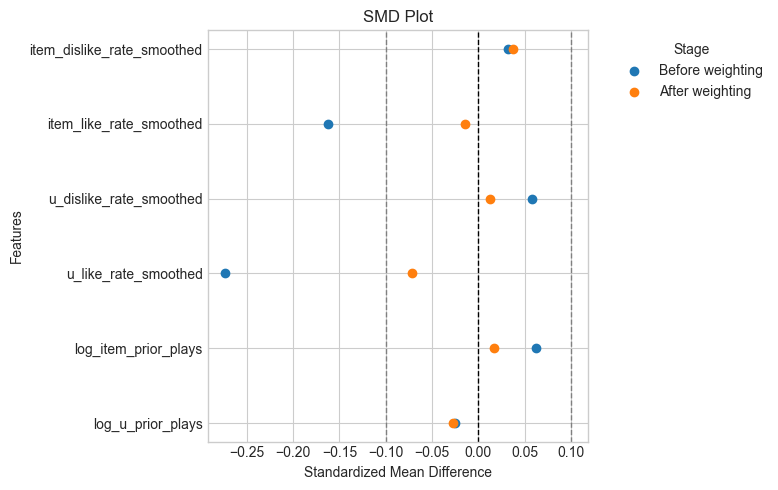

In [6]:
# smd plot

cols = [
    "log_u_prior_plays",
    "log_item_prior_plays",
    "u_like_rate_smoothed",
    "u_dislike_rate_smoothed",
    "item_like_rate_smoothed",
    "item_dislike_rate_smoothed"
]

estimator.smd_plot(segment, cols)

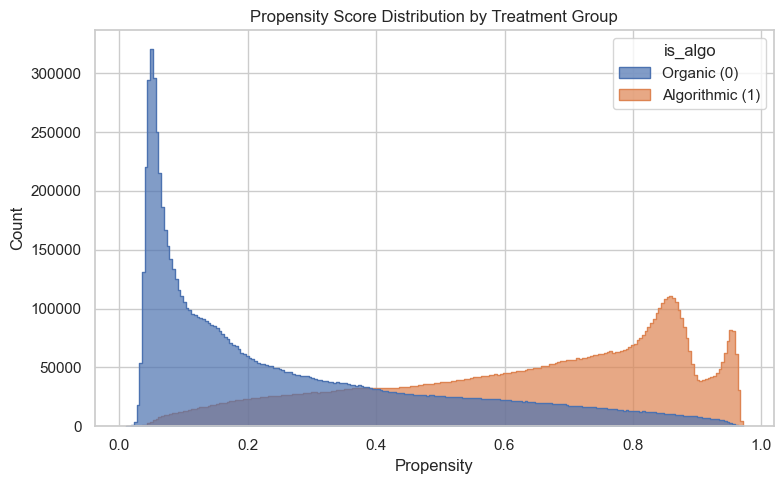

In [6]:
# distribution plot
estimator.propensity_distribution_plot(segment)